In [250]:
import os
import numpy as np
import pandas as pd
from scipy.signal import correlate
import matplotlib.pyplot as plt

from utils.plot_utils import setup_matplotlib

In [251]:
setup_matplotlib()

In [252]:
file_name = "square_20251017"
run = 1
file_name_sim = f'{file_name}.parquet'
file_name_real = f'{file_name}_run{run}.csv'
df_sim = pd.read_parquet(os.path.join('../data/sim', file_name_sim))
df_real = pd.read_csv(os.path.join('../data/real/raw/csv', file_name_real))
df_real = df_real.rename(columns={'torch_yaw': 'torque_yaw'})
# Rename all columns containing 'setpoint' → replace with '_r'
df_real = df_real.rename(
    columns={col: col.replace('setpoint', 'r') for col in df_real.columns if 'setpoint' in col}
)

### Remove take-off and landing

In [253]:
def align_signals(df_ref, df_target, col="x_r", t_col="t", remove_offset=True):
    """
    Align df_target to df_ref in time (via cross-correlation on `col`),
    shift df_target in time, trim to overlapping window,
    and optionally remove constant offsets for all numeric columns.

    Args:
        df_ref : reference DataFrame
        df_target : target DataFrame (to be aligned)
        col : column used for cross-correlation (default: "x_r")
        t_col : time column (default: "t")
        remove_offset : if True, remove constant offsets for all numeric columns

    Returns:
        df_target_aligned, lag_time, corr, lags
    """
    from scipy.signal import correlate

    # signals for cross-correlation
    sig_ref = df_ref[col].to_numpy()
    sig_tgt = df_target[col].to_numpy()

    # normalize
    sig_ref_n = (sig_ref - np.mean(sig_ref)) / np.std(sig_ref)
    sig_tgt_n = (sig_tgt - np.mean(sig_tgt)) / np.std(sig_tgt)

    # cross-correlation
    corr = correlate(sig_ref_n, sig_tgt_n, mode="full")
    lags = np.arange(-len(sig_tgt) + 1, len(sig_ref))
    best_lag = lags[np.argmax(corr)]

    # convert to seconds
    dt = np.mean(np.diff(df_ref[t_col]))
    lag_time = best_lag * dt

    # shift timeline
    df_aligned = df_target.copy()
    df_aligned[t_col] = df_aligned[t_col] + lag_time

    # trim overlap
    t_min = max(df_ref[t_col].min(), df_aligned[t_col].min())
    t_max = min(df_ref[t_col].max(), df_aligned[t_col].max())
    df_aligned = df_aligned[(df_aligned[t_col] >= t_min) & (df_aligned[t_col] <= t_max)].reset_index(drop=True)

    # --- remove constant offsets for all numeric columns ---
    if remove_offset:
        common_cols = set(df_ref.columns).intersection(df_aligned.columns)

        for c in common_cols:
            if np.issubdtype(df_ref[c].dtype, np.number):
                offset = (df_aligned[c] - df_ref[c]).mean()
                df_aligned[c] -= offset

                # Also correct corresponding "_mocap" column if it exists
                mocap_col = f"{c}_mocap"
                if mocap_col in df_aligned.columns:
                    offset_mocap = (df_aligned[mocap_col] - df_ref[c]).mean()
                    df_aligned[mocap_col] -= offset_mocap


    return df_aligned, lag_time, corr, lags

In [254]:
df_real_aligned, lag_time, corr, lags = align_signals(df_sim, df_real, col="x_r")
df_real_aligned = df_real_aligned.bfill()
t_vec = df_sim['t'].to_numpy()

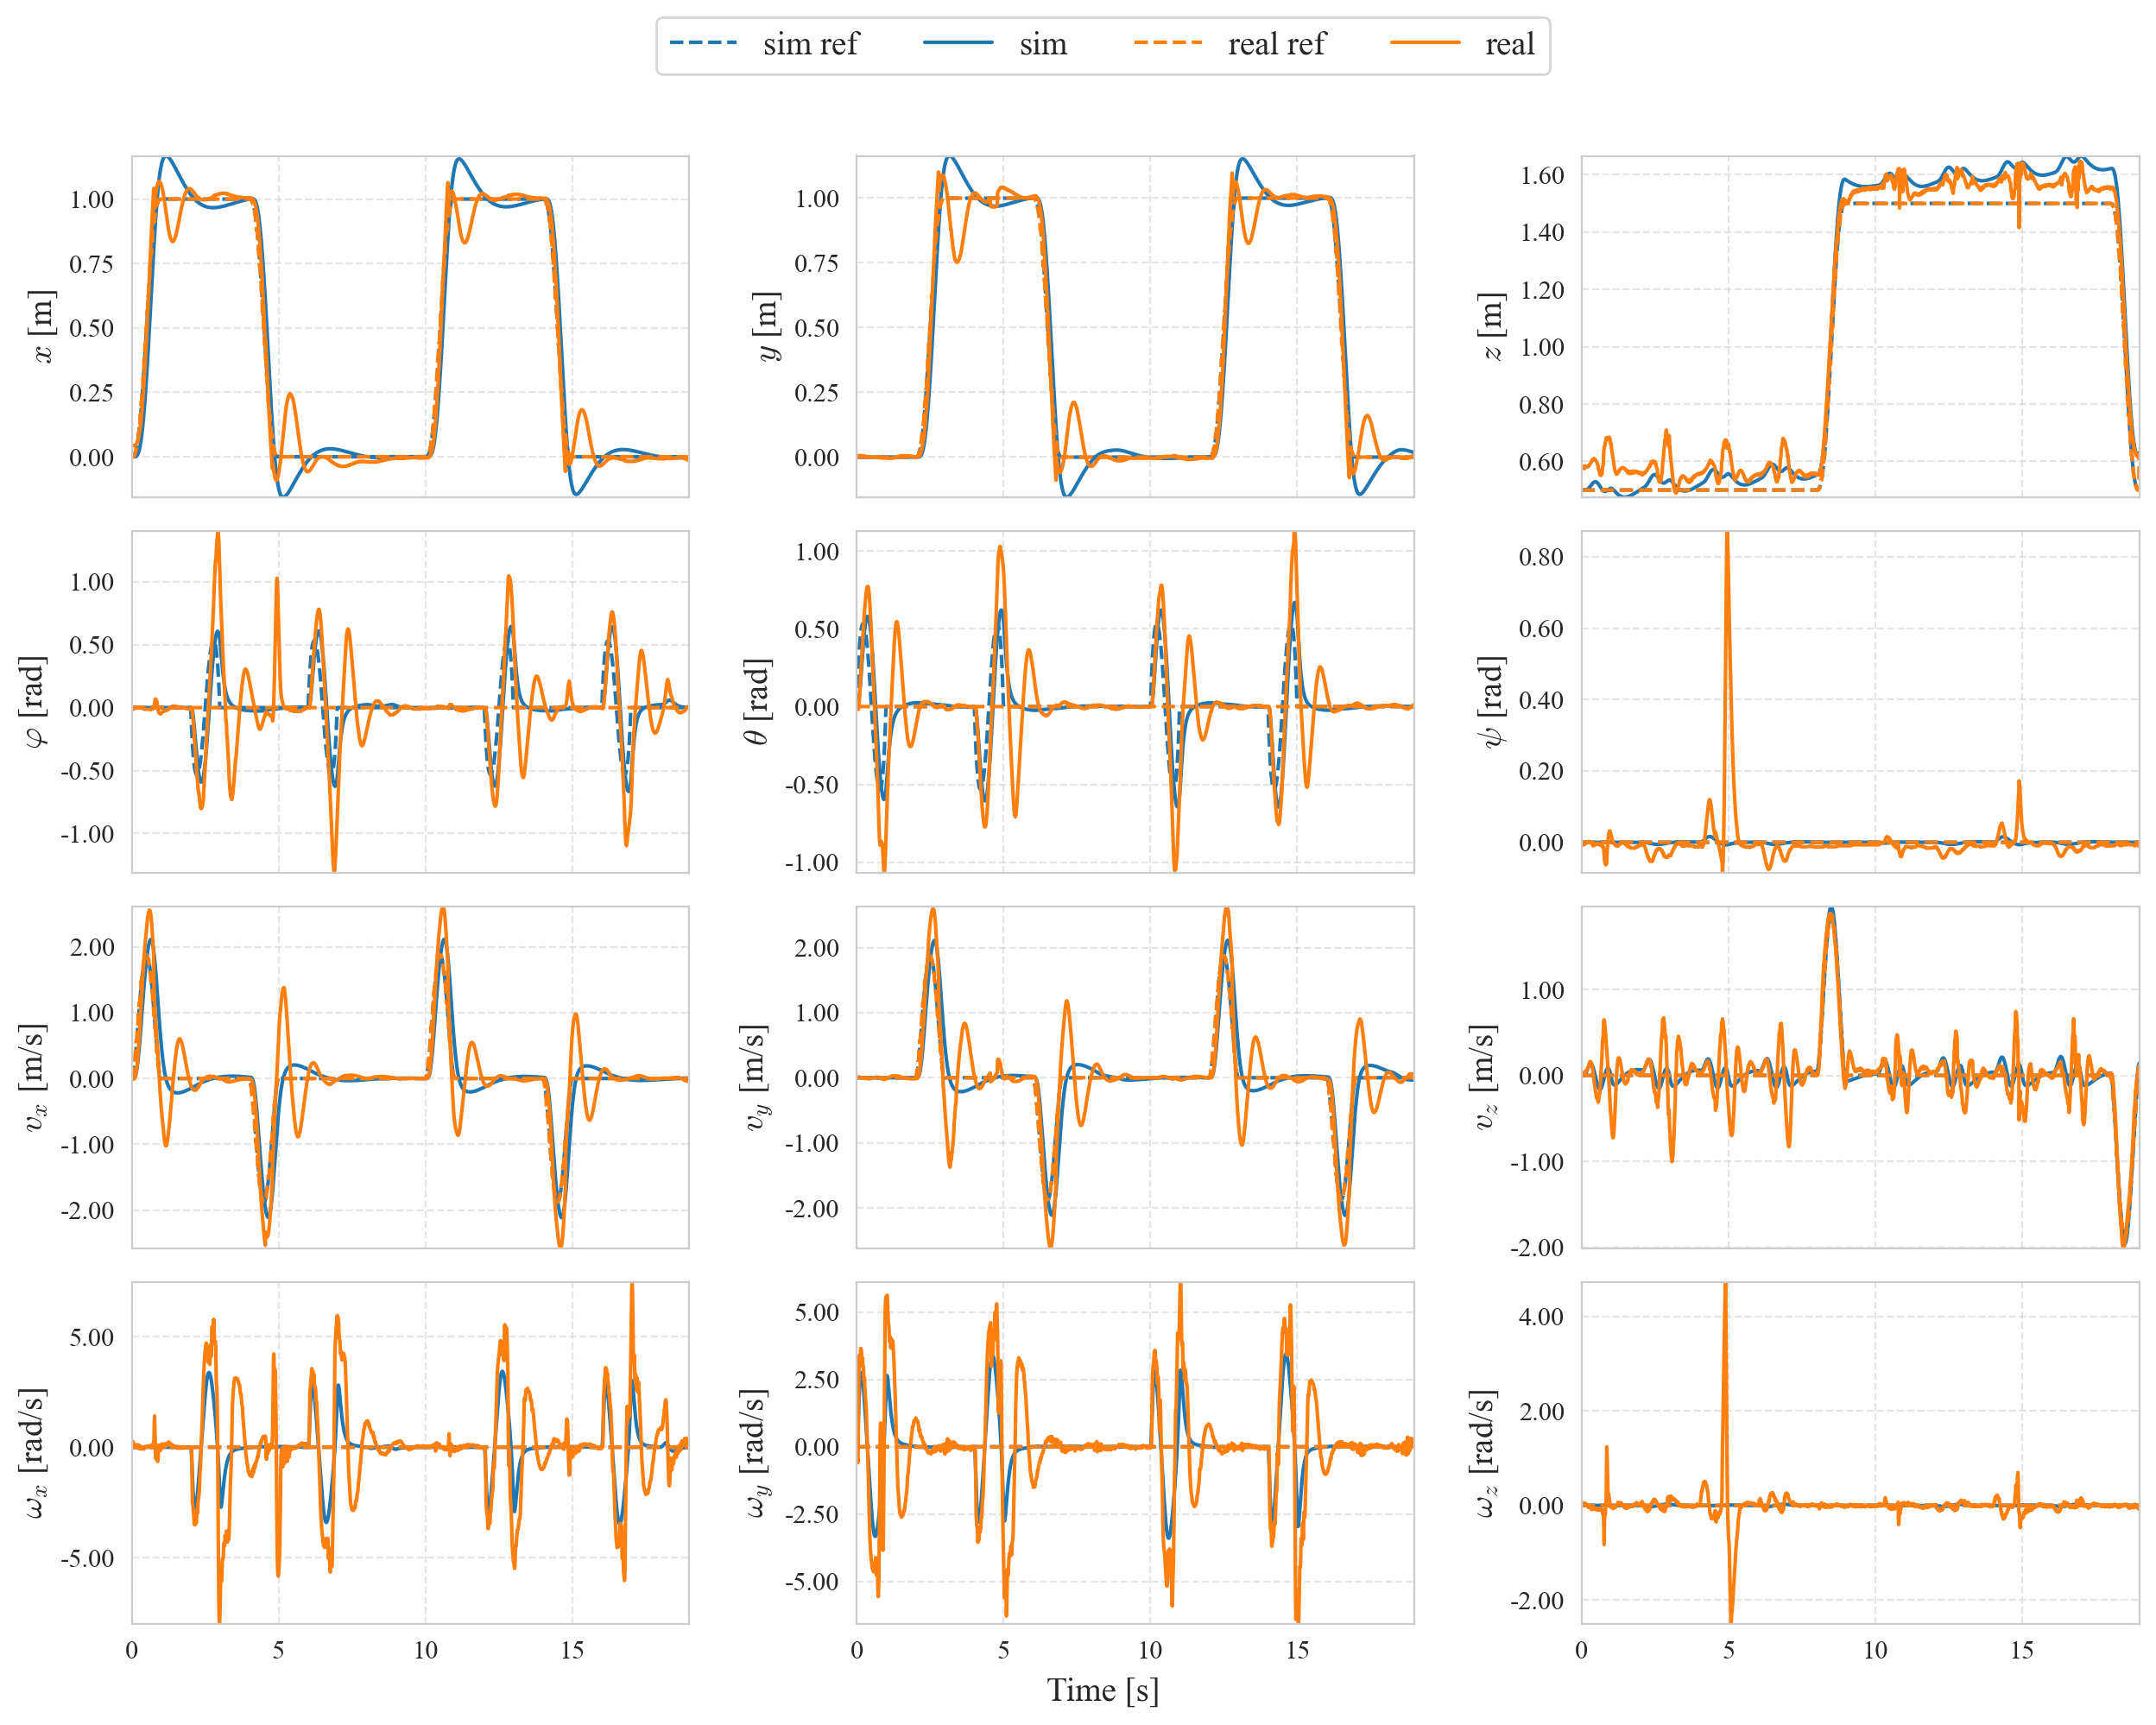

In [255]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Create 4x3 layout (no input column) ---
fig, axs = plt.subplots(4, 3, figsize=(15, 10), sharex=True, dpi=200)

# --- Define state variables ---
state_cols = [
    ['x', 'y', 'z'],
    ['roll', 'pitch', 'yaw'],
    ['vx', 'vy', 'vz'],
    ['wx', 'wy', 'wz']
]
state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]

# --- Plot states ---
for r in range(4):          # rows
    for c in range(3):      # 3 columns for states
        col = state_cols[r][c]
        ax = axs[r, c]

        # sim vs ref
        if f'{col}_r' in df_sim.columns:
            ax.plot(t_vec, df_sim[f'{col}_r'], color='tab:blue', linestyle="--", label="sim ref")
        if col in df_sim.columns:
            ax.plot(t_vec, df_sim[col], color='tab:blue', label="sim")

        # real vs ref
        if f'{col}_r' in df_real_aligned.columns:
            ax.plot(df_real_aligned['t'], df_real_aligned[f'{col}_r'], color='tab:orange', linestyle="--", label="real ref")
        if col in df_real_aligned.columns:
            ax.plot(df_real_aligned['t'], df_real_aligned[col], color='tab:orange', label="real")

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# --- Shared X label ---
fig.text(0.5, 0.04, "Time [s]", ha='center', va='center', fontsize=14)

# --- Collect all unique legend entries ---
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

# --- Combined legend ---
fig.legend(handles, labels, loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.02))

# --- Layout tweaks ---
plt.subplots_adjust(top=0.93, bottom=0.08, hspace=0.1, wspace=0.3)
plt.show()


### Convert ERPM to RAD/S

In [256]:
import numpy as np
import pandas as pd

def convert_erpm_to_rads(df: pd.DataFrame, motor_prefixes=('m1', 'm2', 'm3', 'm4')) -> pd.DataFrame:
    """
    Convert motor speeds from ERPM (electrical RPM) to rad/s and add squared terms.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing columns like 'm1_erpm', 'm2_erpm', etc.
    motor_prefixes : tuple[str]
        Motor identifiers to process.

    Returns
    -------
    pd.DataFrame
        Updated DataFrame with new columns '<motor>_rads' (rad/s)
        and '<motor>_rads2' (squared angular speeds).
    """
    # Electrical RPM → mechanical RPM → rad/s
    # Conversion factor: 1 ERPM = (2π / (poles * 60)) rad/s
    # Crazyflie brushless motors have 6 electrical poles.
    ERPM_TO_RADS = 2 * np.pi / (6 * 60)

    for m in motor_prefixes:
        src_col = f"{m}_erpm"
        if src_col not in df.columns:
            print(f"[WARN] Skipping {src_col}: column not found.")
            continue

        w_rads = df[src_col] * ERPM_TO_RADS
        df[f"{m}_rads"] = w_rads
        df[f"{m}_rads2"] = w_rads**2

    return df

In [257]:
df_real_aligned = convert_erpm_to_rads(df_real_aligned)

In [258]:
import numpy as np

def quat_to_so3_log(q: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    Quaternion → so(3) logarithmic map.
    Converts unit quaternions [x, y, z, w] to rotation vectors in R^3.

    Parameters
    ----------
    q : np.ndarray, shape (..., 4)
        Quaternion(s) in [x, y, z, w] format.
    eps : float
        Numerical stability constant.

    Returns
    -------
    log_q : np.ndarray, shape (..., 3)
        Rotation vector(s) corresponding to the input quaternion(s).
    """
    v = q[..., :3]         # vector part (x, y, z)
    w = q[..., 3:]         # scalar part
    norm_v = np.linalg.norm(v, axis=-1, keepdims=True)

    # Clamp w to [-1, 1] to avoid invalid atan2
    w_clamped = np.clip(w, -1.0 + eps, 1.0 - eps)
    angle = 2.0 * np.arctan2(norm_v, w_clamped)

    # Default log map
    log_q = (angle / (norm_v + eps)) * v

    # For very small angles, use linear approximation: log(q) ≈ 2v
    small = norm_v < eps
    if np.any(small):
        log_q[small[..., 0]] = 2.0 * v[small[..., 0]]

    return log_q

def so3_log_to_quat(rvec: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    so(3) exponential map.
    Converts rotation vectors in R^3 to unit quaternions [x, y, z, w].

    Parameters
    ----------
    rvec : np.ndarray, shape (..., 3)
        Rotation vectors.
    eps : float
        Numerical stability constant.

    Returns
    -------
    q : np.ndarray, shape (..., 4)
        Unit quaternions [x, y, z, w].
    """
    angle = np.linalg.norm(rvec, axis=-1, keepdims=True)
    half_angle = 0.5 * angle
    sin_half = np.sin(half_angle) / (angle + eps)

    q_xyz = sin_half * rvec
    q_w = np.cos(half_angle)
    q = np.concatenate([q_xyz, q_w], axis=-1)

    # Handle very small angles with first-order approximation
    small = angle < eps
    if np.any(small):
        q[small[..., 0], :3] = 0.5 * rvec[small[..., 0]]
        q[small[..., 0], 3] = 1.0

    # Normalize to unit length
    q /= np.linalg.norm(q, axis=-1, keepdims=True)
    return q

In [259]:
q = df_real_aligned[['qx', 'qy', 'qz', 'qw']].to_numpy()
df_real_aligned[['rx', 'ry', 'rz']] = quat_to_so3_log(q, eps=1e-6)

### Filtering

In [260]:
from scipy.signal import butter, sosfiltfilt

# ------------------------------------------------------
# Generic helpers
# ------------------------------------------------------
def design_lowpass(cutoff_hz: float, fs: float, order: int = 4):
    return butter(order, cutoff_hz, btype="low", fs=fs, output="sos")


def _interp_small_gaps(series: pd.Series, max_gap: int = 10) -> pd.Series:
    """Interpolate NaNs only for gaps up to max_gap samples; leave longer gaps NaN."""
    s = series.copy()
    if not s.isna().any():
        return s
    is_nan = s.isna().to_numpy()
    idx = np.arange(len(s))
    fwd = pd.Series(np.where(is_nan, np.nan, idx)).ffill().to_numpy()
    bwd = pd.Series(np.where(is_nan, np.nan, idx)).bfill().to_numpy()
    gap_len = np.where(is_nan, bwd - fwd + 1, 0)
    s_masked = s.mask((is_nan) & (gap_len > max_gap))
    return s_masked.interpolate(limit_direction="both")


def _filter_series(x: np.ndarray, sos, order: int = 4) -> np.ndarray:
    if np.count_nonzero(~np.isnan(x)) < max(3 * order, 20):
        return x
    try:
        return sosfiltfilt(sos, np.nan_to_num(x, nan=np.nanmean(x)))
    except ValueError:
        return x


# ------------------------------------------------------
# Main filtering function
# ------------------------------------------------------
def filter_dataframe(
    df: pd.DataFrame,
    fs: float = 100.0,
    order: int = 4,
    cutoffs: dict[str, tuple[list[str], float]] | None = None,
    discrete_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Apply zero-phase low-pass filtering to numeric columns,
    including quaternions (via log-map).
    """
    out = df.copy()
    discrete_cols = set(discrete_cols or [])

    default_cutoffs = {
        "pos":      ([c for c in ["x", "y", "z"] if c in df.columns], 10.0),
        "euler":    ([c for c in ["roll", "pitch", "yaw"] if c in df.columns], 12.0),
        "vel":      ([c for c in ["vx", "vy", "vz", "wx", "wy", "wz"] if c in df.columns], 18.0),
        "acc":      ([c for c in ["ax", "ay", "az"] if c in df.columns], 25.0),
        "motors":   ([c for c in df.columns if c.endswith(("_rads", "_rads2", "_thrust"))], 30.0),
        "inputs":   ([c for c in ["thrust", "torque_roll", "torque_pitch", "torque_yaw"] if c in df.columns], 20.0),
    }

    if cutoffs is not None:
        default_cutoffs.update(cutoffs)

    numeric_cols = set(out.select_dtypes(include=[np.number]).columns)

    # --- Standard numeric filtering ---
    for group, (cols, fc) in default_cutoffs.items():
        cols = [c for c in cols if c in numeric_cols and c not in discrete_cols]
        if not cols:
            continue
        sos = design_lowpass(fc, fs, order)
        print(f"Filtering {group} ({len(cols)} signals) at {fc} Hz")
        for c in cols:
            s = _interp_small_gaps(out[c])
            out[c] = _filter_series(s.to_numpy(dtype=float), sos, order)

    # --- Quaternion filtering (log-map) ---
    quat_groups = [
        ["qx", "qy", "qz", "qw"],
        ["qx_r", "qy_r", "qz_r", "qw_r"],
        ["qx_poses", "qy_poses", "qz_poses", "qw_poses"],
    ]
    for qcols in quat_groups:
        if not all(c in out.columns for c in qcols):
            continue
        print(f"Filtering quaternion group {qcols[0][:-1]}* at 12 Hz")
        sos = design_lowpass(12.0, fs, order)
        q = out[qcols].to_numpy()
        rvec = quat_to_so3_log(q)
        rvec_filt = np.vstack([_filter_series(rvec[:, i], sos, order) for i in range(3)]).T
        q_filt = so3_log_to_quat(rvec_filt)
        out[qcols] = q_filt

    return out


In [261]:
df_filt = filter_dataframe(
    df_real_aligned,
    fs=100.0,
    order=4
)

Filtering pos (3 signals) at 10.0 Hz
Filtering euler (3 signals) at 12.0 Hz
Filtering vel (6 signals) at 18.0 Hz
Filtering acc (3 signals) at 25.0 Hz
Filtering motors (12 signals) at 30.0 Hz
Filtering inputs (4 signals) at 20.0 Hz
Filtering quaternion group q* at 12 Hz
Filtering quaternion group qx_* at 12 Hz
Filtering quaternion group qx_pose* at 12 Hz


In [262]:
df_filt.to_csv(os.path.join('../data/real/processed/train', file_name_real))

<Axes: >

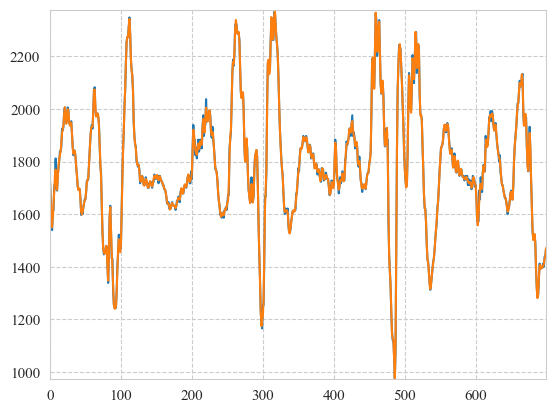

In [263]:
N_start = 0
N_end = N_start + 700
# df_sim['wy'][N_start:N_end].plot()
df_real_aligned['m1_rads'][N_start:N_end].plot()
df_filt['m1_rads'][N_start:N_end].plot()